### IMPORT

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### IMPORT CSV

In [4]:
df = pd.read_csv('multicollinearity_pls_mlr_dataset_v2.csv')

### PLOT FUNCTION

In [5]:
def plot_feature_correlations(df, target_col=None, features=None, figsize_multiplier=4, 
                              n_cols=3, show_stats=True, save_plot=False, 
                              filename='feature_correlations.png'):
    """
    Tạo scatter plots cho tất cả các features so với target column.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    target_col : str, optional
        Tên cột target (biến phụ thuộc). Nếu None, sẽ yêu cầu chọn
    features : list, optional
        Danh sách features cụ thể để vẽ. Nếu None, dùng tất cả cột trừ target
    figsize_multiplier : int, default=4
        Hệ số nhân cho chiều cao mỗi hàng subplot
    n_cols : int, default=3
        Số cột trong grid subplot
    show_stats : bool, default=True
        Hiển thị thống kê correlation và target variable
    save_plot : bool, default=False
        Lưu biểu đồ ra file
    filename : str, default='feature_correlations.png'
        Tên file khi lưu
    
    Returns:
    --------
    fig, axes : matplotlib figure và axes objects
    """
    
    # Kiểm tra và chọn target column
    if target_col is None:
        print("\n" + "="*60)
        print("CHỌN TARGET COLUMN")
        print("="*60)
        print("Các cột có sẵn trong DataFrame:")
        for idx, col in enumerate(df.columns):
            print(f"  {idx+1}. {col}")
        
        while True:
            try:
                choice = input("\nNhập số thứ tự của target column: ")
                choice_idx = int(choice) - 1
                if 0 <= choice_idx < len(df.columns):
                    target_col = df.columns[choice_idx]
                    print(f"✓ Đã chọn target column: {target_col}")
                    break
                else:
                    print("⚠️  Số không hợp lệ. Vui lòng chọn lại.")
            except ValueError:
                print("⚠️  Vui lòng nhập số.")
    
    # Kiểm tra target column có tồn tại
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' không tồn tại trong DataFrame!")
    
    # Lấy danh sách features
    if features is None:
        features = [col for col in df.columns if col != target_col]
    else:
        # Kiểm tra features có hợp lệ
        invalid_features = [f for f in features if f not in df.columns]
        if invalid_features:
            raise ValueError(f"Features không tồn tại: {invalid_features}")
        # Loại bỏ target_col nếu có trong features
        features = [f for f in features if f != target_col]
    
    if len(features) == 0:
        raise ValueError("Không có features nào để vẽ!")
    
    n_features = len(features)
    
    # Màu sắc cho từng subplot
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # XỬ LÝ TRƯỜNG HỢP ĐẶC BIỆT: CHỈ 1 FEATURE
    if n_features == 1:
        # Tạo figure vuông đẹp cho 1 feature
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        fig.suptitle(f'Scatter Plot: {features[0]} vs {target_col}', 
                     fontsize=16, fontweight='bold', y=0.98)
        
        feature = features[0]
        
        # Kiểm tra dữ liệu hợp lệ
        valid_data = df[[feature, target_col]].dropna()
        
        if len(valid_data) > 0:
            # Scatter plot
            ax.scatter(valid_data[feature], valid_data[target_col], 
                      alpha=0.6, s=50, color=colors[0],
                      edgecolors='black', linewidth=0.5)
            
            # Tính correlation
            corr = valid_data[feature].corr(valid_data[target_col])
            
            # Thiết lập labels và title
            ax.set_xlabel(feature, fontsize=12, fontweight='bold')
            ax.set_ylabel(f'{target_col}', fontsize=12, fontweight='bold')
            ax.set_title(f'Correlation: {corr:.3f} | Sample size: {len(valid_data)}', 
                        fontsize=11, pad=10)
            
            # Grid
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Màu nền dựa trên correlation
            if abs(corr) > 0.5:
                ax.set_facecolor('#fff5f5' if corr < 0 else '#f5fff5')
        else:
            ax.text(0.5, 0.5, f'No valid data for {feature}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=14)
        
        plt.tight_layout()
        
        # Lưu biểu đồ nếu được yêu cầu
        if save_plot:
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"\n✓ Biểu đồ đã được lưu: {filename}")
        
        # In thống kê nếu được yêu cầu
        if show_stats:
            print_correlation_stats(df, features, target_col)
        
        return fig, ax
    
    # XỬ LÝ TRƯỜNG HỢP NHIỀU FEATURES
    n_rows = int(np.ceil(n_features / n_cols))
    
    # Tạo figure và axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * figsize_multiplier))
    fig.suptitle(f'Scatter Plots of Features vs {target_col}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Flatten axes - XỬ LÝ TẤT CẢ CÁC TRƯỜNG HỢP
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])  # Chuyển thành array
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()  # Đã là 1D array
    else:
        axes = axes.flatten()  # 2D array -> 1D array
    
    # Vẽ từng feature
    for idx, feature in enumerate(features):
        ax = axes[idx]
        
        # Kiểm tra dữ liệu hợp lệ
        valid_data = df[[feature, target_col]].dropna()
        
        if len(valid_data) == 0:
            ax.text(0.5, 0.5, f'No valid data for {feature}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(feature, fontsize=12, fontweight='bold')
            continue
        
        # Scatter plot
        ax.scatter(valid_data[feature], valid_data[target_col], 
                  alpha=0.6, s=30, color=colors[idx % len(colors)],
                  edgecolors='black', linewidth=0.5)
        
        # Tính correlation
        corr = valid_data[feature].corr(valid_data[target_col])
        
        # Thiết lập labels và title
        ax.set_xlabel(feature, fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{target_col}', fontsize=11, fontweight='bold')
        ax.set_title(f'{feature} vs {target_col}\n(Correlation: {corr:.3f}, n={len(valid_data)})', 
                    fontsize=12, fontweight='bold')
        
        # Grid
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Màu nền dựa trên correlation
        if abs(corr) > 0.5:
            ax.set_facecolor('#fff5f5' if corr < 0 else '#f5fff5')
    
    # Ẩn các subplot thừa
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    # Lưu biểu đồ nếu được yêu cầu
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"\n✓ Biểu đồ đã được lưu: {filename}")
    
    # In thống kê nếu được yêu cầu
    if show_stats:
        print_correlation_stats(df, features, target_col)
    
    return fig, axes


def print_correlation_stats(df, features, target_col):
    """
    In thông tin correlation và thống kê của target variable.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    features : list
        Danh sách tên features
    target_col : str
        Tên cột target
    """
    # In correlation
    print("\n" + "=" * 70)
    print(f"TƯƠNG QUAN GIỮA CÁC ĐẶC TRƯNG VÀ {target_col}")
    print("=" * 70)
    
    correlations = df[features].corrwith(df[target_col]).sort_values(ascending=False)
    
    print(f"{'Feature':<30} {'Correlation':>12} {'Strength':>20}")
    print("-" * 70)
    
    for feature, corr in correlations.items():
        # Đánh giá độ mạnh correlation
        if abs(corr) >= 0.7:
            strength = "Very Strong"
        elif abs(corr) >= 0.5:
            strength = "Strong"
        elif abs(corr) >= 0.3:
            strength = "Moderate"
        elif abs(corr) >= 0.1:
            strength = "Weak"
        else:
            strength = "Very Weak"
        
        bar = '█' * int(abs(corr) * 30)
        print(f"{feature:<30} {corr:>12.4f} {bar:>20} ({strength})")
    
    print("=" * 70)
    
    # In thống kê target variable
    print("\n" + "=" * 70)
    print(f"THỐNG KÊ {target_col}")
    print("=" * 70)
    print(f"Count:  {df[target_col].count():>10.0f}")
    print(f"Mean:   {df[target_col].mean():>10.4f}")
    print(f"Median: {df[target_col].median():>10.4f}")
    print(f"Std:    {df[target_col].std():>10.4f}")
    print(f"Min:    {df[target_col].min():>10.4f}")
    print(f"Max:    {df[target_col].max():>10.4f}")
    print(f"Range:  {df[target_col].max() - df[target_col].min():>10.4f}")
    print("=" * 70)


def select_target_interactive(df):
    """
    Hàm helper để chọn target column một cách tương tác.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    
    Returns:
    --------
    str : Tên target column đã chọn
    """
    print("\n" + "="*60)
    print("CHỌN TARGET COLUMN")
    print("="*60)
    print("Các cột có sẵn trong DataFrame:")
    
    for idx, col in enumerate(df.columns):
        dtype = df[col].dtype
        n_unique = df[col].nunique()
        print(f"  {idx+1:2d}. {col:30s} (dtype: {dtype}, unique: {n_unique})")
    
    while True:
        try:
            choice = input("\nNhập số thứ tự của target column: ")
            choice_idx = int(choice) - 1
            if 0 <= choice_idx < len(df.columns):
                target_col = df.columns[choice_idx]
                print(f"✓ Đã chọn target column: {target_col}")
                return target_col
            else:
                print("⚠️  Số không hợp lệ. Vui lòng chọn lại.")
        except ValueError:
            print("⚠️  Vui lòng nhập số.")
        except KeyboardInterrupt:
            print("\n⚠️  Đã hủy.")
            return None

### MLR TRAIN FUNCTION

In [10]:
def train_mlr_model_with_animation(df, target_col, test_size=0.2, val_size=0.25, random_state=42, 
                    save_plots=True, plot_prefix='mlr', show_info=True,
                    use_gradient_descent=False, learning_rate=0.01, n_iterations=1000,
                    show_convergence=True, animate_steps=False, animation_interval=100):
    """
    Huấn luyện Multiple Linear Regression model với khả năng animation từng bước Gradient Descent.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    target_col : str
        Tên cột target (biến phụ thuộc)
    test_size : float, default=0.2
        Tỷ lệ test set (0.2 = 20%)
    val_size : float, default=0.25
        Tỷ lệ validation từ phần còn lại (0.25 của 80% = 20% tổng)
    random_state : int, default=42
        Seed để tái tạo kết quả
    save_plots : bool, default=True
        Lưu biểu đồ ra file
    plot_prefix : str, default='mlr'
        Tiền tố cho tên file khi lưu
    show_info : bool, default=True
        Hiển thị thông tin chi tiết
    use_gradient_descent : bool, default=False
        Sử dụng Gradient Descent thay vì Normal Equation
    learning_rate : float, default=0.01
        Tốc độ học cho Gradient Descent
    n_iterations : int, default=1000
        Số lần lặp của Gradient Descent
    show_convergence : bool, default=True
        Hiển thị biểu đồ hội tụ của Gradient Descent
    animate_steps : bool, default=False
        Hiển thị animation từng bước của Gradient Descent
    animation_interval : int, default=100
        Số iterations giữa mỗi frame animation
    
    Returns:
    --------
    dict : Dictionary chứa model và các kết quả
    """
    
    if show_info:
        print("=" * 60)
        print("THÔNG TIN DỮ LIỆU")
        print("=" * 60)
        print(f"Số lượng mẫu: {len(df)}")
        print(f"Các đặc trưng: {df.columns.tolist()}")
        print(f"\nThống kê mô tả:")
        print(df.describe())
    
    # Chuẩn bị dữ liệu
    X = df.drop([target_col], axis=1)
    y = df[target_col]
    
    if show_info:
        print(f"\n{'=' * 60}")
        print(f"CÁC ĐẶC TRƯNG INPUT")
        print("=" * 60)
        print(f"Số lượng đặc trưng: {X.shape[1]}")
        print(f"Tên các đặc trưng: {X.columns.tolist()}")
    
    # Chia dữ liệu: train, validation, test
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, random_state=random_state)
    
    if show_info:
        print(f"\n{'=' * 60}")
        print("PHÂN CHIA DỮ LIỆU")
        print("=" * 60)
        print(f"Train set: {len(X_train)} mẫu ({len(X_train)/len(df)*100:.1f}%)")
        print(f"Validation set: {len(X_val)} mẫu ({len(X_val)/len(df)*100:.1f}%)")
        print(f"Test set: {len(X_test)} mẫu ({len(X_test)/len(df)*100:.1f}%)")
    
    # Tạo và huấn luyện model
    cost_history = None
    theta_history = None
    
    if use_gradient_descent:
        if show_info:
            print(f"\n{'=' * 60}")
            print("GRADIENT DESCENT")
            print("=" * 60)
            print(f"Learning rate: {learning_rate}")
            print(f"Số lần lặp: {n_iterations}")
        
        # Chuẩn hóa dữ liệu cho Gradient Descent
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)
        
        # Implement Gradient Descent
        m = len(X_train_scaled)
        n_features = X_train_scaled.shape[1]
        
        # Thêm bias term (cột 1)
        X_train_bias = np.c_[np.ones(m), X_train_scaled]
        
        # Khởi tạo theta
        theta = np.zeros(n_features + 1)
        
        # Lưu lại history
        cost_history = []
        theta_history = []
        
        # Gradient Descent
        for i in range(n_iterations):
            # Tính prediction
            predictions = X_train_bias.dot(theta)
            
            # Tính error
            errors = predictions - y_train.values
            
            # Tính cost (MSE)
            cost = (1/(2*m)) * np.sum(errors**2)
            cost_history.append(cost)
            theta_history.append(theta.copy())
            
            # Tính gradient
            gradient = (1/m) * X_train_bias.T.dot(errors)
            
            # Cập nhật theta
            theta = theta - learning_rate * gradient
            
            # In progress mỗi 100 iterations
            if show_info and (i % 100 == 0 or i == n_iterations - 1):
                print(f"Iteration {i:4d}: Cost = {cost:.4f}")
        
        # Tạo model wrapper để tương thích
        class GradientDescentModel:
            def __init__(self, theta, scaler):
                self.intercept_ = theta[0]
                self.coef_ = theta[1:]
                self.scaler = scaler
                self.theta = theta
            
            def predict(self, X):
                X_scaled = self.scaler.transform(X)
                X_bias = np.c_[np.ones(len(X_scaled)), X_scaled]
                return X_bias.dot(self.theta)
        
        model = GradientDescentModel(theta, scaler)
        
        if show_info:
            print(f"\nGradient Descent hoàn tất!")
            print(f"Cost cuối cùng: {cost_history[-1]:.4f}")
            print(f"Cost ban đầu: {cost_history[0]:.4f}")
            print(f"Giảm: {cost_history[0] - cost_history[-1]:.4f}")
        
        # ANIMATION TỪNG BƯỚC
        if animate_steps and cost_history is not None:
            print(f"\n{'=' * 60}")
            print("TẠO ANIMATION GRADIENT DESCENT")
            print("=" * 60)
            
            # Tạo danh sách các iteration để hiển thị
            display_iterations = list(range(0, n_iterations, animation_interval))
            if (n_iterations - 1) not in display_iterations:
                display_iterations.append(n_iterations - 1)
            
            n_display = len(display_iterations)
            
            # ========================================
            # 1. COST EVOLUTION - MỘT PLOT DUY NHẤT
            # ========================================
            fig_cost, ax_cost = plt.subplots(1, 1, figsize=(12, 6))
            
            # Vẽ toàn bộ cost history
            ax_cost.plot(range(n_iterations), cost_history, 
                        linewidth=2, color='blue', alpha=0.7, label='Cost History')
            
            # Đánh dấu các điểm tại display_iterations bằng chấm đỏ
            display_costs = [cost_history[i] for i in display_iterations]
            ax_cost.scatter(display_iterations, display_costs, 
                           color='red', s=100, zorder=5, label='Animation Steps', 
                           edgecolors='black', linewidth=1.5)
            
            # Thêm annotation cho các điểm quan trọng
            for idx, iteration in enumerate(display_iterations):
                if idx % max(1, len(display_iterations) // 5) == 0:  # Chỉ label một số điểm
                    ax_cost.annotate(f'Iter {iteration}', 
                                    xy=(iteration, cost_history[iteration]),
                                    xytext=(10, 10), textcoords='offset points',
                                    fontsize=8, alpha=0.7,
                                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            ax_cost.set_xlabel('Iteration', fontsize=12, fontweight='bold')
            ax_cost.set_ylabel('Cost (MSE)', fontsize=12, fontweight='bold')
            ax_cost.set_title('Gradient Descent - Cost Evolution\n(Red dots = Animation Steps)', 
                            fontsize=14, fontweight='bold')
            ax_cost.grid(True, alpha=0.3)
            ax_cost.legend(fontsize=10)
            
            plt.tight_layout()
            
            if save_plots:
                filename = f'{plot_prefix}_gd_cost_evolution.png'
                plt.savefig(filename, dpi=300, bbox_inches='tight')
                print(f"Biểu đồ cost evolution đã lưu: {filename}")
            
            plt.show()
            
                        # ========================================
            # 2. MODEL EVOLUTION - MỖI ITERATION STEP MỘT FIGURE
            # ========================================
            n_features_plot = X.shape[1]
            feature_names = X.columns.tolist()
            
            # Tính số cột cho subplot (tối đa 3 cột)
            n_cols_feat = min(3, n_features_plot)
            n_rows_feat = int(np.ceil(n_features_plot / n_cols_feat))
            
            # Lặp qua từng iteration step
            for iter_idx, iteration in enumerate(display_iterations):
                # Tạo figure cho iteration này
                fig_iter, axes_iter = plt.subplots(n_rows_feat, n_cols_feat, 
                                                   figsize=(6*n_cols_feat, 5*n_rows_feat))
                
                if n_features_plot == 1:
                    axes_iter = [axes_iter]
                else:
                    axes_iter = axes_iter.flatten()
                
                # Lấy theta tại iteration này
                current_theta = theta_history[iteration]
                current_cost = cost_history[iteration]
                
                fig_iter.suptitle(f'Model at Iteration {iteration} (Cost = {current_cost:.4f})', 
                                 fontsize=16, fontweight='bold')
                
                # Vẽ cho từng feature
                for feat_idx, feature_name in enumerate(feature_names):
                    ax = axes_iter[feat_idx]
                    
                    # Vẽ scatter plot của dữ liệu thực (GỐC - CHƯA CHUẨN HÓA)
                    ax.scatter(X_train[feature_name], y_train, 
                              alpha=0.4, s=30, color='blue', 
                              edgecolors='black', linewidth=0.5,
                              label='Training Data')
                    
                    # Lấy hệ số cho feature này (TRÊN DỮ LIỆU ĐÃ CHUẨN HÓA)
                    intercept_scaled = current_theta[0]
                    coef_scaled = current_theta[feat_idx + 1]
                    
                    # Tạo range cho x (GỐC - CHƯA CHUẨN HÓA)
                    x_range = np.linspace(X_train[feature_name].min(), 
                                         X_train[feature_name].max(), 100)
                    
                    # Chuẩn hóa x_range
                    x_range_scaled = (x_range - scaler.mean_[feat_idx]) / scaler.scale_[feat_idx]
                    
                    # Tính giá trị dự đoán trên thang đo đã chuẩn hóa
                    y_pred_scaled = intercept_scaled + coef_scaled * x_range_scaled
                    
                    # QUAN TRỌNG: Chuyển y_pred về thang đo gốc
                    # y_train cũng đã được chuẩn hóa, nên cần inverse transform
                    # Nhưng ở đây y_train chưa chuẩn hóa trong code
                    # Vậy y_pred_scaled là sai vì nó đang ở thang chuẩn hóa
                    
                    # PHƯƠNG PHÁP ĐÚNG: Tính hệ số trên thang đo gốc
                    # Từ model: y_scaled = intercept_scaled + coef_scaled * x_scaled
                    # Với x_scaled = (x - mean_x) / std_x
                    # => y_scaled = intercept_scaled + coef_scaled * (x - mean_x) / std_x
                    # => y = intercept_scaled + coef_scaled * (x - mean_x) / std_x
                    
                    # Vẽ đường regression trên thang gốc
                    y_pred = intercept_scaled + coef_scaled * x_range_scaled
                    
                    # Tính hệ số trên thang gốc để hiển thị
                    # slope = coef_scaled / std_x
                    # intercept = intercept_scaled - slope * mean_x
                    slope_original = coef_scaled / scaler.scale_[feat_idx]
                    intercept_original = intercept_scaled - slope_original * scaler.mean_[feat_idx]
                    
                    # Vẽ đường regression
                    ax.plot(x_range, y_pred, 
                           color='red', 
                           linewidth=3,
                           label=f'Model: y = {intercept_original:.2f} + {slope_original:.2f}x',
                           alpha=0.8)
                    
                    ax.set_xlabel(feature_name, fontsize=11, fontweight='bold')
                    ax.set_ylabel(target_col, fontsize=11, fontweight='bold')
                    ax.set_title(f'{feature_name} vs {target_col}\nScaled Coef = {coef_scaled:.4f}, Original Coef = {slope_original:.4f}', 
                               fontsize=11, fontweight='bold')
                    ax.grid(True, alpha=0.3)
                    ax.legend(fontsize=9, loc='best')
                
                # Ẩn axes thừa
                for idx in range(n_features_plot, len(axes_iter)):
                    axes_iter[idx].set_visible(False)
                
                plt.tight_layout()
                
                if save_plots:
                    filename = f'{plot_prefix}_gd_model_iter_{iteration:04d}.png'
                    plt.savefig(filename, dpi=300, bbox_inches='tight')
                    if show_info and iter_idx % max(1, n_display // 5) == 0:
                        print(f"Biểu đồ model iteration {iteration} đã lưu: {filename}")
                
                plt.show()
            
            if save_plots:
                print(f"\nĐã lưu {n_display} biểu đồ model evolution!")
            
            # ========================================
            # 3. COEFFICIENT TRAJECTORIES (giữ nguyên như cũ)
            # ========================================
            fig_traj, ax_traj = plt.subplots(figsize=(14, 8))
            
            theta_array = np.array(theta_history)
            feature_names_full = ['Intercept'] + feature_names
            
            for i, name in enumerate(feature_names_full):
                ax_traj.plot(theta_array[:, i], linewidth=2, label=name, alpha=0.8)
                # Đánh dấu các điểm quan trọng
                for disp_iter in display_iterations:
                    ax_traj.scatter([disp_iter], [theta_array[disp_iter, i]], 
                                   s=50, zorder=5)
            
            ax_traj.set_xlabel('Iteration', fontsize=12, fontweight='bold')
            ax_traj.set_ylabel('Coefficient Value', fontsize=12, fontweight='bold')
            ax_traj.set_title('Gradient Descent - Coefficient Trajectories', 
                            fontsize=14, fontweight='bold')
            ax_traj.grid(True, alpha=0.3)
            ax_traj.legend(loc='best', fontsize=10)
            ax_traj.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
            
            plt.tight_layout()
            
            if save_plots:
                filename = f'{plot_prefix}_gd_trajectories.png'
                plt.savefig(filename, dpi=300, bbox_inches='tight')
                print(f"Biểu đồ coefficient trajectories đã lưu: {filename}")
            
            plt.show()
        
    else:
        from sklearn.linear_model import LinearRegression
        model = LinearRegression()
        model.fit(X_train, y_train)
    
    if show_info:
        print(f"\n{'=' * 60}")
        print("HUẤN LUYỆN MODEL HOÀN TẤT")
        print("=" * 60)
    
    # Dự đoán
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Tính metrics
    def calculate_metrics(y_true, y_pred, dataset_name):
        from sklearn.metrics import mean_absolute_error
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        if show_info:
            print(f"\n{dataset_name}:")
            print(f"  MSE:  {mse:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE:  {mae:.4f}")
            print(f"  R²:   {r2:.4f}")
        
        return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    
    if show_info:
        print(f"\n{'=' * 60}")
        print("KẾT QUẢ ĐÁNH GIÁ MODEL")
        print("=" * 60)
    
    train_metrics = calculate_metrics(y_train, y_train_pred, "TRAIN SET")
    val_metrics = calculate_metrics(y_val, y_val_pred, "VALIDATION SET")
    test_metrics = calculate_metrics(y_test, y_test_pred, "TEST SET")
    
    # Hiển thị hệ số
    if show_info:
        print(f"\n{'=' * 60}")
        print("HỆ SỐ CỦA MODEL")
        print("=" * 60)
        print(f"Intercept (hệ số chặn): {model.intercept_:.4f}")
        print(f"\nHệ số của các đặc trưng:")
        for feature, coef in zip(X.columns, model.coef_):
            print(f"  {feature:25s}: {coef:10.4f}")
    
    # Vẽ biểu đồ convergence nếu dùng Gradient Descent
    if use_gradient_descent and show_convergence and cost_history is not None and not animate_steps:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Cost history
        axes[0].plot(cost_history, linewidth=2)
        axes[0].set_xlabel('Iteration', fontsize=12)
        axes[0].set_ylabel('Cost (MSE)', fontsize=12)
        axes[0].set_title('Gradient Descent - Cost History', fontsize=14)
        axes[0].grid(True, alpha=0.3)
        
        # Cost history (log scale) - dễ nhìn hơn
        axes[1].semilogy(cost_history, linewidth=2)
        axes[1].set_xlabel('Iteration', fontsize=12)
        axes[1].set_ylabel('Cost (MSE) - Log Scale', fontsize=12)
        axes[1].set_title('Gradient Descent - Cost History (Log Scale)', fontsize=14)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_plots:
            filename = f'{plot_prefix}_gradient_descent.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            if show_info:
                print(f"\nBiểu đồ Gradient Descent đã được lưu: {filename}")
        
        plt.show()
    
    # Vẽ biểu đồ so sánh
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    datasets = [
        (y_train, y_train_pred, 'Train Set', train_metrics),
        (y_val, y_val_pred, 'Validation Set', val_metrics),
        (y_test, y_test_pred, 'Test Set', test_metrics)
    ]
    
    for idx, (y_true, y_pred, title, metrics) in enumerate(datasets):
        axes[idx].scatter(y_true, y_pred, alpha=0.6, edgecolors='k', s=50)
        
        # Đường y=x
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        axes[idx].set_xlabel('Giá trị thực tế', fontsize=12)
        axes[idx].set_ylabel('Giá trị dự đoán', fontsize=12)
        axes[idx].set_title(f'{title}\nR² = {metrics["R2"]:.4f}, RMSE = {metrics["RMSE"]:.4f}', fontsize=12)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        filename = f'{plot_prefix}_results.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        if show_info:
            print(f"\n{'=' * 60}")
            print(f"Biểu đồ đã được lưu: {filename}")
            print("=" * 60)
    
    plt.show()
    
    # Vẽ biểu đồ phần dư
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, (y_true, y_pred, title, metrics) in enumerate(datasets):
        residuals = y_true - y_pred
        axes[idx].scatter(y_pred, residuals, alpha=0.6, edgecolors='k', s=50)
        axes[idx].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[idx].set_xlabel('Giá trị dự đoán', fontsize=12)
        axes[idx].set_ylabel('Phần dư (Residuals)', fontsize=12)
        axes[idx].set_title(f'Residual Plot - {title}', fontsize=12)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        filename = f'{plot_prefix}_residuals.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        if show_info:
            print(f"Biểu đồ phần dư đã được lưu: {filename}")
    
    plt.show()
    
    if show_info:
        print(f"\n{'=' * 60}")
        print("HOÀN TẤT!")
        print("=" * 60)
    
    # Trả về kết quả
    result = {
        'model': model,
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_val_pred': y_val_pred,
        'y_test_pred': y_test_pred,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'feature_names': X.columns.tolist(),
        'coefficients': dict(zip(X.columns, model.coef_)),
        'intercept': model.intercept_
    }
    
    # Thêm gradient descent info nếu có
    if use_gradient_descent and cost_history is not None:
        result['cost_history'] = cost_history
        result['theta_history'] = theta_history
        result['learning_rate'] = learning_rate
        result['n_iterations'] = n_iterations
    
    return result

### VIF MULTICOLINEARITY FUNCTION

In [15]:
def check_multicollinearity_vif(df, features=None, threshold=10, show_info=True):
    """
    Kiểm tra đa cộng tuyến (multicollinearity) sử dụng VIF (Variance Inflation Factor).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    features : list, optional
        Danh sách tên cột cần kiểm tra. Nếu None, kiểm tra tất cả cột số
    threshold : float, default=10
        Ngưỡng VIF (VIF > threshold => có đa cộng tuyến)
        - VIF < 5: Không có vấn đề
        - 5 <= VIF < 10: Đa cộng tuyến vừa phải
        - VIF >= 10: Đa cộng tuyến nghiêm trọng
    show_info : bool, default=True
        Hiển thị thông tin chi tiết
    
    Returns:
    --------
    dict : Dictionary chứa kết quả
        {
            'vif_data': DataFrame với VIF của từng feature,
            'high_vif_features': list các feature có VIF > threshold,
            'max_vif': giá trị VIF cao nhất,
            'mean_vif': giá trị VIF trung bình,
            'has_multicollinearity': True/False
        }
    """
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # Nếu không chỉ định features, lấy tất cả cột số
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Chuẩn bị dữ liệu
    X = df[features].values
    
    if show_info:
        print("\n" + "="*70)
        print("KIỂM TRA ĐA CỘNG TUYẾN (VIF - Variance Inflation Factor)")
        print("="*70)
        print(f"Số lượng features: {len(features)}")
        print(f"Ngưỡng VIF: {threshold}")
        print("\nHướng dẫn:")
        print("  VIF < 5:      Không có vấn đề")
        print("  5 <= VIF < 10: Đa cộng tuyến vừa phải")
        print("  VIF >= 10:     Đa cộng tuyến nghiêm trọng")
    
    # Tính VIF cho từng feature
    vif_data = []
    for i, feature in enumerate(features):
        try:
            vif_value = variance_inflation_factor(X, i)
            vif_data.append({
                'Feature': feature,
                'VIF': vif_value
            })
        except Exception as e:
            if show_info:
                print(f"Lỗi khi tính VIF cho {feature}: {e}")
            vif_data.append({
                'Feature': feature,
                'VIF': np.nan
            })
    
    # Tạo DataFrame
    vif_df = pd.DataFrame(vif_data)
    vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
    
    # Phân loại
    vif_df['Status'] = vif_df['VIF'].apply(
        lambda x: 'Nghiêm trọng' if x >= 10 
        else ('Vừa phải' if x >= 5 else 'OK') if not np.isnan(x) else 'N/A'
    )
    
    # Tìm features có VIF cao
    high_vif_features = vif_df[vif_df['VIF'] >= threshold]['Feature'].tolist()
    
    # Tính toán thống kê
    max_vif = vif_df['VIF'].max()
    mean_vif = vif_df['VIF'].mean()
    has_multicollinearity = len(high_vif_features) > 0
    
    if show_info:
        print("\n" + "="*70)
        print("KẾT QUẢ VIF")
        print("="*70)
        print(vif_df.to_string(index=False))
        
        print("\n" + "="*70)
        print("THỐNG KÊ")
        print("="*70)
        print(f"VIF cao nhất: {max_vif:.2f} ({vif_df.iloc[0]['Feature']})")
        print(f"VIF trung bình: {mean_vif:.2f}")
        print(f"Số features có VIF >= {threshold}: {len(high_vif_features)}")
        
        if has_multicollinearity:
            print(f"\n⚠️  CẢNH BÁO: Phát hiện đa cộng tuyến!")
            print(f"Các features có VIF >= {threshold}:")
            for feat in high_vif_features:
                vif_val = vif_df[vif_df['Feature'] == feat]['VIF'].values[0]
                print(f"  - {feat}: VIF = {vif_val:.2f}")
        else:
            print(f"\n✓ KHÔNG phát hiện đa cộng tuyến nghiêm trọng (tất cả VIF < {threshold})")
        
        print("="*70)
    
    return {
        'vif_data': vif_df,
        'high_vif_features': high_vif_features,
        'max_vif': max_vif,
        'mean_vif': mean_vif,
        'has_multicollinearity': has_multicollinearity,
        'threshold': threshold,
        'features': features
    }


def visualize_vif(vif_results, figsize=(12, 6)):
    """
    Trực quan hóa kết quả VIF.
    
    Parameters:
    -----------
    vif_results : dict
        Kết quả từ check_multicollinearity_vif()
    figsize : tuple, default=(12, 6)
        Kích thước figure
    """
    vif_df = vif_results['vif_data']
    threshold = vif_results['threshold']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Bar chart
    colors = ['red' if vif >= 10 else ('orange' if vif >= 5 else 'green') 
              for vif in vif_df['VIF']]
    
    ax1.barh(vif_df['Feature'], vif_df['VIF'], color=colors, alpha=0.7, edgecolor='black')
    ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Ngưỡng = {threshold}')
    ax1.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
                label='VIF = 5')
    ax1.set_xlabel('VIF Value', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Features', fontsize=12, fontweight='bold')
    ax1.set_title('Variance Inflation Factor (VIF)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Thêm giá trị VIF lên bar
    for idx, (feat, vif) in enumerate(zip(vif_df['Feature'], vif_df['VIF'])):
        ax1.text(vif + 0.5, idx, f'{vif:.2f}', va='center', fontsize=9, fontweight='bold')
    
    # Plot 2: Heatmap correlation matrix
    features = vif_results['features']
    corr_matrix = pd.DataFrame(
        np.corrcoef(vif_df.index.map(lambda i: features.index(vif_df.iloc[i]['Feature']))),
        index=vif_df['Feature'],
        columns=vif_df['Feature']
    )
    
    # Sử dụng correlation từ df gốc nếu có
    im = ax2.imshow(corr_matrix.abs(), cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax2.set_xticks(range(len(vif_df)))
    ax2.set_yticks(range(len(vif_df)))
    ax2.set_xticklabels(vif_df['Feature'], rotation=45, ha='right', fontsize=9)
    ax2.set_yticklabels(vif_df['Feature'], fontsize=9)
    ax2.set_title('Correlation Matrix (Absolute)', fontsize=13, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('|Correlation|', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


def remove_high_vif_features(df, features=None, threshold=10, max_iterations=10, 
                             show_info=True):
    """
    Loại bỏ lần lượt các features có VIF cao nhất cho đến khi tất cả VIF < threshold.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    features : list, optional
        Danh sách features ban đầu
    threshold : float, default=10
        Ngưỡng VIF
    max_iterations : int, default=10
        Số lần lặp tối đa
    show_info : bool, default=True
        Hiển thị thông tin
    
    Returns:
    --------
    dict : Dictionary chứa kết quả
        {
            'final_features': list features còn lại,
            'removed_features': list features đã loại bỏ,
            'final_vif_results': kết quả VIF cuối cùng,
            'iteration_history': lịch sử các bước loại bỏ
        }
    """
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    
    current_features = features.copy()
    removed_features = []
    iteration_history = []
    
    if show_info:
        print("\n" + "="*70)
        print("LOẠI BỎ FEATURES VỚI VIF CAO")
        print("="*70)
        print(f"Số features ban đầu: {len(current_features)}")
        print(f"Ngưỡng VIF: {threshold}")
        print(f"Số vòng lặp tối đa: {max_iterations}")
    
    for iteration in range(max_iterations):
        # Tính VIF cho features hiện tại
        X = df[current_features].values
        vif_data = []
        
        for i, feature in enumerate(current_features):
            try:
                vif_value = variance_inflation_factor(X, i)
                vif_data.append({'Feature': feature, 'VIF': vif_value})
            except:
                vif_data.append({'Feature': feature, 'VIF': np.nan})
        
        vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
        max_vif = vif_df['VIF'].max()
        max_vif_feature = vif_df.iloc[0]['Feature']
        
        iteration_history.append({
            'iteration': iteration + 1,
            'n_features': len(current_features),
            'max_vif': max_vif,
            'max_vif_feature': max_vif_feature,
            'features': current_features.copy()
        })
        
        if show_info:
            print(f"\n--- Iteration {iteration + 1} ---")
            print(f"Số features: {len(current_features)}")
            print(f"VIF cao nhất: {max_vif:.2f} ({max_vif_feature})")
        
        # Kiểm tra điều kiện dừng
        if max_vif < threshold:
            if show_info:
                print(f"✓ Tất cả VIF < {threshold}. Dừng lại.")
            break
        
        # Loại bỏ feature có VIF cao nhất
        current_features.remove(max_vif_feature)
        removed_features.append(max_vif_feature)
        
        if show_info:
            print(f"→ Loại bỏ: {max_vif_feature}")
        
        # Kiểm tra còn ít nhất 1 feature
        if len(current_features) == 0:
            if show_info:
                print("⚠️  CẢNH BÁO: Đã loại bỏ tất cả features!")
            break
    
    # Tính VIF cuối cùng
    final_vif_results = check_multicollinearity_vif(
        df, 
        features=current_features, 
        threshold=threshold,
        show_info=False
    )
    
    if show_info:
        print("\n" + "="*70)
        print("KẾT QUẢ CUỐI CÙNG")
        print("="*70)
        print(f"Features ban đầu: {len(features)}")
        print(f"Features còn lại: {len(current_features)}")
        print(f"Features đã loại: {len(removed_features)}")
        print(f"\nFeatures còn lại: {current_features}")
        print(f"\nFeatures đã loại bỏ: {removed_features}")
        print("\nVIF cuối cùng:")
        print(final_vif_results['vif_data'].to_string(index=False))
        print("="*70)
    
    return {
        'final_features': current_features,
        'removed_features': removed_features,
        'final_vif_results': final_vif_results,
        'iteration_history': iteration_history,
        'n_iterations': len(iteration_history)
    }


def plot_vif_reduction_process(removal_results):
    """
    Vẽ biểu đồ quá trình giảm VIF.
    
    Parameters:
    -----------
    removal_results : dict
        Kết quả từ remove_high_vif_features()
    """
    history = removal_results['iteration_history']
    
    iterations = [h['iteration'] for h in history]
    max_vifs = [h['max_vif'] for h in history]
    n_features = [h['n_features'] for h in history]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Max VIF qua các iteration
    ax1.plot(iterations, max_vifs, marker='o', linewidth=2, markersize=8, 
             color='red', label='Max VIF')
    ax1.axhline(y=removal_results['final_vif_results']['threshold'], 
                color='orange', linestyle='--', linewidth=2, label='Ngưỡng')
    ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Max VIF', fontsize=12, fontweight='bold')
    ax1.set_title('Quá trình giảm VIF', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # Thêm annotation
    for i, (iter, vif, feat) in enumerate(zip(iterations, max_vifs, 
                                               [h['max_vif_feature'] for h in history])):
        if i < len(iterations) - 1:  # Không annotation cho iteration cuối
            ax1.annotate(feat, xy=(iter, vif), xytext=(5, 5), 
                        textcoords='offset points', fontsize=8, alpha=0.7)
    
    # Plot 2: Số features qua các iteration
    ax2.plot(iterations, n_features, marker='s', linewidth=2, markersize=8, 
             color='blue', label='Số features')
    ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Số Features', fontsize=12, fontweight='bold')
    ax2.set_title('Số Features còn lại', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

### OUTLIER FUNCTION

In [9]:
from scipy.stats import chi2


def detect_outliers_hampel(df, columns=None, threshold=3, show_summary=True):
    """
    Phát hiện outliers cho tất cả các cột sử dụng Hampel Filter / MAD.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    columns : list, optional
        Danh sách tên cột cần kiểm tra. Nếu None, kiểm tra tất cả cột số
    threshold : float, default=3
        Ngưỡng MAD (thường dùng 3)
    show_summary : bool, default=True
        Hiển thị tóm tắt kết quả
    
    Returns:
    --------
    dict : Dictionary chứa kết quả
        {
            'outlier_summary': dict với thông tin chi tiết từng cột,
            'all_outliers_mask': boolean array của các mẫu có ít nhất 1 outlier,
            'clean_mask': boolean array của các mẫu không có outlier nào,
            'df_clean': DataFrame sau khi loại bỏ outliers,
            'df_outliers': DataFrame chỉ chứa các outliers
        }
    """
    
    # Nếu không chỉ định columns, lấy tất cả cột số
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    def hampel_filter_mad(data, threshold=3):
        """Phát hiện outliers bằng Hampel Filter / MAD"""
        median = np.median(data)
        mad = np.median(np.abs(data - median))
        
        # Công thức chuẩn hóa MAD
        mad_std = 1.4826 * mad
        
        # Tính modified z-score
        if mad_std != 0:
            modified_z_scores = (data - median) / mad_std
        else:
            modified_z_scores = np.zeros_like(data) 
        
        outliers_mask = np.abs(modified_z_scores) > threshold
        
        return outliers_mask, mad, median
    
    outlier_summary = {}
    all_outliers_mask = np.zeros(len(df), dtype=bool)
    
    if show_summary:
        print("\n" + "="*70)
        print("KẾT QUẢ PHÁT HIỆN OUTLIERS (HAMPEL FILTER / MAD)")
        print("="*70)
    
    for feature in columns:
        outliers_mask, mad, median = hampel_filter_mad(df[feature].values, threshold)
        
        num_outliers = outliers_mask.sum()
        outlier_percentage = (num_outliers / len(df)) * 100
        
        outlier_summary[feature] = {
            'count': num_outliers,
            'percentage': outlier_percentage,
            'mad': mad,
            'median': median,
            'mask': outliers_mask,
            'outlier_indices': np.where(outliers_mask)[0].tolist()
        }
        
        # Cộng dồn mask
        all_outliers_mask |= outliers_mask
        
        if show_summary:
            print(f"\n{feature}:")
            print(f"  Median: {median:.2f}")
            print(f"  MAD: {mad:.2f}")
            print(f"  Số outliers: {num_outliers} ({outlier_percentage:.1f}%)")
            
            if num_outliers > 0:
                outlier_values = df[feature].values[outliers_mask]
                print(f"  Giá trị outliers: min={outlier_values.min():.2f}, max={outlier_values.max():.2f}")
    
    # Tạo mask cho dữ liệu sạch (không có outlier)
    clean_mask = ~all_outliers_mask
    
    if show_summary:
        print("\n" + "="*70)
        print(f"TỔNG SỐ MẪU CÓ ÍT NHẤT 1 OUTLIER: {all_outliers_mask.sum()} ({all_outliers_mask.sum()/len(df)*100:.1f}%)")
        print(f"TỔNG SỐ MẪU SẠCH (KHÔNG CÓ OUTLIER): {clean_mask.sum()} ({clean_mask.sum()/len(df)*100:.1f}%)")
        print("="*70)
    
    return {
        'outlier_summary': outlier_summary,
        'all_outliers_mask': all_outliers_mask,
        'clean_mask': clean_mask,
        'df_clean': df[clean_mask].copy(),
        'df_outliers': df[all_outliers_mask].copy(),
        'threshold': threshold,
        'columns_checked': columns
    }


def visualize_outliers(df, outlier_results, figsize=(15, 10)):
    """
    Trực quan hóa outliers bằng boxplot.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame gốc
    outlier_results : dict
        Kết quả từ detect_outliers_hampel()
    figsize : tuple, default=(15, 10)
        Kích thước figure
    """
    columns = outlier_results['columns_checked']
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if len(columns) > 1 else [axes]
    
    for idx, col in enumerate(columns):
        ax = axes[idx]
        
        # Boxplot
        bp = ax.boxplot(df[col], vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        
        # Đánh dấu outliers
        outlier_mask = outlier_results['outlier_summary'][col]['mask']
        if outlier_mask.sum() > 0:
            outlier_values = df[col].values[outlier_mask]
            outlier_positions = np.ones(len(outlier_values))
            ax.scatter(outlier_positions, outlier_values, color='red', 
                      s=50, alpha=0.6, label='Outliers', zorder=5)
        
        # Thông tin
        num_outliers = outlier_results['outlier_summary'][col]['count']
        percentage = outlier_results['outlier_summary'][col]['percentage']
        
        ax.set_title(f'{col}\nOutliers: {num_outliers} ({percentage:.1f}%)', 
                    fontsize=10, fontweight='bold')
        ax.set_ylabel('Giá trị', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if outlier_mask.sum() > 0:
            ax.legend(fontsize=8)
    
    # Ẩn subplot thừa
    for idx in range(len(columns), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Phát hiện Outliers - Hampel Filter/MAD', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


def compare_datasets(df_original, df_clean, title_prefix=""):
    """
    So sánh dataset gốc và dataset sau khi loại bỏ outliers.
    
    Parameters:
    -----------
    df_original : pandas.DataFrame
        DataFrame gốc
    df_clean : pandas.DataFrame
        DataFrame đã loại bỏ outliers
    title_prefix : str, optional
        Tiền tố cho tiêu đề
    """
    print("\n" + "="*70)
    print(f"{title_prefix}SO SÁNH DATASET")
    print("="*70)
    print(f"Dataset gốc: {len(df_original)} mẫu")
    print(f"Dataset sạch: {len(df_clean)} mẫu")
    print(f"Số mẫu bị loại bỏ: {len(df_original) - len(df_clean)} ({(1 - len(df_clean)/len(df_original))*100:.1f}%)")
    print("="*70)
    
    print("\nThống kê mô tả - DATASET GỐC:")
    print(df_original.describe())
    
    print("\nThống kê mô tả - DATASET SẠCH:")
    print(df_clean.describe())

def detect_outliers_multivariate_pca(df, features=None, variance_threshold=0.95, 
                                      alpha=0.01, show_info=True, show_plots=True):
    """
    Phát hiện outliers đa biến sử dụng PCA (Hotelling T² và Q-statistic).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    features : list, optional
        Danh sách tên cột để phân tích. Nếu None, dùng tất cả cột số
    variance_threshold : float, default=0.95
        Ngưỡng phương sai tích lũy để chọn số PC (0.95 = 95%)
    alpha : float, default=0.01
        Mức ý nghĩa thống kê (0.01 = 99% confidence)
    show_info : bool, default=True
        Hiển thị thông tin chi tiết
    show_plots : bool, default=True
        Hiển thị biểu đồ
    
    Returns:
    --------
    dict : Dictionary chứa kết quả
        {
            'T2': array của Hotelling T² values,
            'Q': array của Q-statistic values,
            'T2_threshold': ngưỡng T²,
            'Q_threshold': ngưỡng Q,
            'T2_outliers_mask': boolean mask cho T² outliers,
            'Q_outliers_mask': boolean mask cho Q outliers,
            'multivariate_outliers_mask': boolean mask kết hợp,
            'df_clean': DataFrame sau khi loại bỏ outliers,
            'pca': PCA object đã fit,
            'scaler': StandardScaler object đã fit,
            'n_pc': số PC được sử dụng,
            'explained_variance_ratio': tỷ lệ phương sai giải thích
        }
    """
    
    # Nếu không chỉ định features, lấy tất cả cột số
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if show_info:
        print(f"\n{'='*70}")
        print("PHÁT HIỆN OUTLIERS ĐA BIẾN (PCA - Hotelling T² và Q-statistic)")
        print(f"{'='*70}")
    
    # Chuẩn bị dữ liệu
    X = df[features].values
    
    # Chuẩn hóa dữ liệu (mean=0, std=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Áp dụng PCA
    n_components = len(features)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    if show_info:
        print(f"\nSố components: {n_components}")
        print(f"Phương sai giải thích bởi từng PC:")
        for i, var in enumerate(pca.explained_variance_ratio_):
            print(f"  PC{i+1}: {var*100:.2f}%")
        print(f"Tổng phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    
    # Chọn số PC để giữ lại
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    n_pc = np.argmax(cumsum_var >= variance_threshold) + 1
    
    if show_info:
        print(f"\nSố PC cần để giữ {variance_threshold*100:.0f}% variance: {n_pc}")
    
    # ----- HOTELLING T² STATISTIC -----
    n_samples = X_pca.shape[0]
    
    # Tính T² cho từng mẫu
    T2 = np.sum((X_pca[:, :n_pc] ** 2) / pca.explained_variance_[:n_pc], axis=1)
    
    # Ngưỡng T² (dựa trên phân phối F)
    from scipy.stats import f
    T2_threshold = (n_pc * (n_samples - 1) * (n_samples + 1)) / \
                   (n_samples * (n_samples - n_pc)) * \
                   f.ppf(1 - alpha, n_pc, n_samples - n_pc)
    
    T2_outliers = T2 > T2_threshold
    n_T2_outliers = T2_outliers.sum()
    
    if show_info:
        print(f"\n--- Hotelling T² Statistic ---")
        print(f"Số PC sử dụng: {n_pc}")
        print(f"Ngưỡng T² (α={alpha}): {T2_threshold:.2f}")
        print(f"T² max: {T2.max():.2f}")
        print(f"Số outliers phát hiện: {n_T2_outliers} ({n_T2_outliers/n_samples*100:.1f}%)")
    
    # ----- Q-STATISTIC (SPE - Squared Prediction Error) -----
    X_reconstructed = pca.inverse_transform(X_pca)
    Q = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)
    
    # Ngưỡng Q (công thức Jackson-Mudholkar)
    theta = [np.sum(pca.explained_variance_[n_pc:] ** i) for i in range(1, 4)]
    h0 = 1 - (2 * theta[0] * theta[2]) / (3 * theta[1] ** 2)
    
    Q_threshold = theta[0] * (
        1 - (theta[1] * h0 * (1 - h0)) / theta[0] ** 2 +
        chi2.ppf(1 - alpha, h0 ** 2) * np.sqrt(2 * theta[1] * h0 ** 2) / theta[0]
    ) ** (1 / h0)
    
    Q_outliers = Q > Q_threshold
    n_Q_outliers = Q_outliers.sum()
    
    if show_info:
        print(f"\n--- Q-statistic (SPE) ---")
        print(f"Ngưỡng Q (α={alpha}): {Q_threshold:.2f}")
        print(f"Q max: {Q.max():.2f}")
        print(f"Số outliers phát hiện: {n_Q_outliers} ({n_Q_outliers/n_samples*100:.1f}%)")
    
    # Kết hợp cả hai tiêu chí
    multivariate_outliers = T2_outliers | Q_outliers
    n_multi_outliers = multivariate_outliers.sum()
    
    if show_info:
        print(f"\n--- Kết hợp T² và Q ---")
        print(f"Tổng số outliers đa biến: {n_multi_outliers} ({n_multi_outliers/n_samples*100:.1f}%)")
    
    # Visualization
    if show_plots:
        _plot_pca_outliers(T2, Q, T2_threshold, Q_threshold, 
                          T2_outliers, Q_outliers, 
                          n_T2_outliers, n_Q_outliers)
    
    # DataFrame sạch
    df_clean = df[~multivariate_outliers].copy()
    
    return {
        'T2': T2,
        'Q': Q,
        'T2_threshold': T2_threshold,
        'Q_threshold': Q_threshold,
        'T2_outliers_mask': T2_outliers,
        'Q_outliers_mask': Q_outliers,
        'multivariate_outliers_mask': multivariate_outliers,
        'df_clean': df_clean,
        'df_outliers': df[multivariate_outliers].copy(),
        'pca': pca,
        'scaler': scaler,
        'n_pc': n_pc,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'X_pca': X_pca,
        'n_outliers': n_multi_outliers,
        'outlier_percentage': n_multi_outliers/n_samples*100,
        'features': features,
        'alpha': alpha
    }


def _plot_pca_outliers(T2, Q, T2_threshold, Q_threshold, 
                       T2_outliers, Q_outliers, 
                       n_T2_outliers, n_Q_outliers):
    """Helper function để vẽ biểu đồ PCA outliers"""
    
    # Plot 1 & 2: T² chart và Q chart
    fig_pca, axes_pca = plt.subplots(1, 2, figsize=(16, 6))
    
    indices = np.arange(len(T2))
    
    # Plot 1: T² chart
    ax1 = axes_pca[0]
    normal_indices = indices[~T2_outliers]
    outlier_indices = indices[T2_outliers]
    
    ax1.scatter(normal_indices, T2[~T2_outliers], c='steelblue', alpha=0.6, s=30, 
               label='Bình thường', edgecolors='black', linewidth=0.5)
    if n_T2_outliers > 0:
        ax1.scatter(outlier_indices, T2[T2_outliers], 
                   c='red', alpha=0.8, s=80, label='Outliers', 
                   edgecolors='darkred', linewidth=1.5, marker='X')
    ax1.axhline(y=T2_threshold, color='orange', linestyle='--', linewidth=2, 
               label=f'Ngưỡng T² = {T2_threshold:.2f}')
    ax1.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Hotelling T²', fontsize=12, fontweight='bold')
    ax1.set_title(f'Hotelling T² Statistic\n({n_T2_outliers} outliers)', 
                 fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # Plot 2: Q chart
    ax2 = axes_pca[1]
    normal_indices_q = indices[~Q_outliers]
    outlier_indices_q = indices[Q_outliers]
    
    ax2.scatter(normal_indices_q, Q[~Q_outliers], c='steelblue', alpha=0.6, s=30, 
               label='Bình thường', edgecolors='black', linewidth=0.5)
    if n_Q_outliers > 0:
        ax2.scatter(outlier_indices_q, Q[Q_outliers], 
                   c='red', alpha=0.8, s=80, label='Outliers', 
                   edgecolors='darkred', linewidth=1.5, marker='X')
    ax2.axhline(y=Q_threshold, color='orange', linestyle='--', linewidth=2, 
               label=f'Ngưỡng Q = {Q_threshold:.2f}')
    ax2.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Q-statistic (SPE)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Q-statistic (Squared Prediction Error)\n({n_Q_outliers} outliers)', 
                 fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 3: T² vs Q scatter plot
    fig_scatter = plt.figure(figsize=(10, 8))
    ax_scatter = fig_scatter.add_subplot(111)
    
    # Vẽ 4 vùng
    both_normal = ~T2_outliers & ~Q_outliers
    only_T2 = T2_outliers & ~Q_outliers
    only_Q = ~T2_outliers & Q_outliers
    both_outlier = T2_outliers & Q_outliers
    
    ax_scatter.scatter(T2[both_normal], Q[both_normal], c='steelblue', alpha=0.6, 
                      s=40, label='Bình thường', edgecolors='black', linewidth=0.5)
    if only_T2.sum() > 0:
        ax_scatter.scatter(T2[only_T2], Q[only_T2], c='orange', alpha=0.7, 
                          s=60, label='Chỉ vi phạm T²', edgecolors='darkorange', linewidth=1, marker='s')
    if only_Q.sum() > 0:
        ax_scatter.scatter(T2[only_Q], Q[only_Q], c='purple', alpha=0.7, 
                          s=60, label='Chỉ vi phạm Q', edgecolors='indigo', linewidth=1, marker='^')
    if both_outlier.sum() > 0:
        ax_scatter.scatter(T2[both_outlier], Q[both_outlier], c='red', alpha=0.9, 
                          s=100, label='Vi phạm cả 2', edgecolors='darkred', linewidth=1.5, marker='X')
    
    ax_scatter.axhline(y=Q_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax_scatter.axvline(x=T2_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax_scatter.set_xlabel('Hotelling T²', fontsize=12, fontweight='bold')
    ax_scatter.set_ylabel('Q-statistic (SPE)', fontsize=12, fontweight='bold')
    ax_scatter.set_title('Biểu đồ T² vs Q\n(Phát hiện outliers đa biến)', 
                        fontsize=14, fontweight='bold')
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()


def compare_outlier_removal(df_original, df_univariate, df_multivariate, 
                            target_col='COD_mgL', features=None):
    """
    So sánh các bước loại bỏ outliers.
    
    Parameters:
    -----------
    df_original : pandas.DataFrame
        DataFrame gốc
    df_univariate : pandas.DataFrame
        DataFrame sau khi loại outliers đơn biến
    df_multivariate : pandas.DataFrame
        DataFrame sau khi loại outliers đa biến
    target_col : str, default='COD_mgL'
        Tên cột target
    features : list, optional
        Danh sách features để so sánh correlation
    """
    
    if features is None:
        features = [col for col in df_original.columns if col != target_col]
    
    print(f"\n{'='*70}")
    print(f"DATASET CUỐI CÙNG (SAU KHI LOẠI BỎ CẢ OUTLIERS ĐƠN BIẾN VÀ ĐA BIẾN)")
    print(f"{'='*70}")
    print(f"Số mẫu ban đầu: {len(df_original)}")
    print(f"Sau loại outliers đơn biến: {len(df_univariate)} (loại bỏ {len(df_original) - len(df_univariate)})")
    print(f"Sau loại outliers đa biến: {len(df_multivariate)} (loại bỏ thêm {len(df_univariate) - len(df_multivariate)})")
    print(f"Tổng số mẫu bị loại: {len(df_original) - len(df_multivariate)} ({(len(df_original) - len(df_multivariate))/len(df_original)*100:.1f}%)")
    print(f"Số mẫu còn lại: {len(df_multivariate)} ({len(df_multivariate)/len(df_original)*100:.1f}%)")
    
    # So sánh correlation
    print(f"\n{'='*70}")
    print("SO SÁNH HỆ SỐ TƯƠNG QUAN:")
    print(f"{'='*70}")
    print(f"{'Feature':<25} {'Ban đầu':<12} {'Loại đơn':<12} {'Loại đa':<12}")
    print("-"*70)
    
    for feature in features:
        corr_original = df_original[target_col].corr(df_original[feature])
        corr_univariate = df_univariate[target_col].corr(df_univariate[feature])
        corr_multivariate = df_multivariate[target_col].corr(df_multivariate[feature])
        
        print(f"{feature:<25} {corr_original:>11.4f} {corr_univariate:>11.4f} {corr_multivariate:>11.4f}")
    
    print("="*70)


def full_outlier_pipeline(df, target_col='COD_mgL', 
                          hampel_threshold=3,
                          pca_variance=0.95,
                          pca_alpha=0.01,
                          show_info=True):
    """
    Pipeline đầy đủ: phát hiện và loại bỏ outliers đơn biến và đa biến.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame gốc
    target_col : str, default='COD_mgL'
        Tên cột target
    hampel_threshold : float, default=3
        Ngưỡng Hampel filter
    pca_variance : float, default=0.95
        Ngưỡng variance cho PCA
    pca_alpha : float, default=0.01
        Mức ý nghĩa thống kê cho PCA
    show_info : bool, default=True
        Hiển thị thông tin
    
    Returns:
    --------
    dict : Dictionary chứa tất cả kết quả
    """
    
    features = [col for col in df.columns if col != target_col]
    
    # Bước 1: Phát hiện outliers đơn biến
    if show_info:
        print("\n" + "="*70)
        print("BƯỚC 1: PHÁT HIỆN OUTLIERS ĐƠN BIẾN")
        print("="*70)
    
    univariate_results = detect_outliers_hampel(
        df, 
        columns=features,
        threshold=hampel_threshold,
        show_summary=show_info
    )
    
    df_after_univariate = univariate_results['df_clean']
    
    # Bước 2: Phát hiện outliers đa biến
    if show_info:
        print("\n" + "="*70)
        print("BƯỚC 2: PHÁT HIỆN OUTLIERS ĐA BIẾN")
        print("="*70)
    
    multivariate_results = detect_outliers_multivariate_pca(
        df_after_univariate,
        features=features,
        variance_threshold=pca_variance,
        alpha=pca_alpha,
        show_info=show_info,
        show_plots=show_info
    )
    
    df_final = multivariate_results['df_clean']
    
    # So sánh
    if show_info:
        compare_outlier_removal(df, df_after_univariate, df_final, 
                               target_col, features)
    
    return {
        'df_original': df,
        'df_after_univariate': df_after_univariate,
        'df_final': df_final,
        'univariate_results': univariate_results,
        'multivariate_results': multivariate_results,
        'total_removed': len(df) - len(df_final),
        'total_removed_pct': (len(df) - len(df_final)) / len(df) * 100
    }

### PLOT DF DEFAULT

In [6]:
# Kiểm tra tên cột thực tế
print("Tên các cột trong DataFrame:")
for i, col in enumerate(df.columns):
    print(f"{i}: '{col}'")
    print(f"   Length: {len(col)}")
    print(f"   Repr: {repr(col)}")
    print()

# Hoặc đơn giản hơn
print("\nDanh sách cột:")
print(df.columns.tolist())

Tên các cột trong DataFrame:
0: 'x1'
   Length: 2
   Repr: 'x1'

1: 'x2'
   Length: 2
   Repr: 'x2'

2: 'y'
   Length: 1
   Repr: 'y'


Danh sách cột:
['x1', 'x2', 'y']


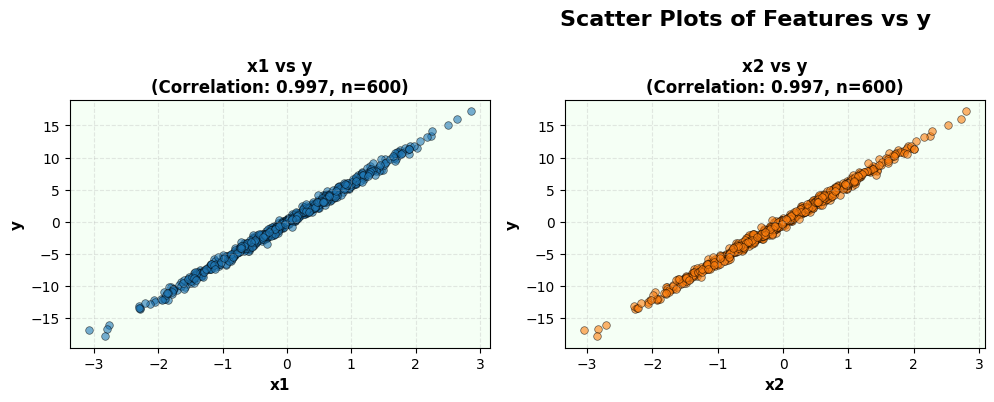

In [7]:
target_col = 'y'
fig, axes = plot_feature_correlations(df, target_col=target_col, show_stats=False)
plt.show()

### TRAIN DF 

THÔNG TIN DỮ LIỆU
Số lượng mẫu: 600
Các đặc trưng: ['x1', 'x2', 'y']

Thống kê mô tả:
               x1          x2           y
count  600.000000  600.000000  600.000000
mean    -0.052589   -0.052989   -0.332791
std      0.979185    0.978412    5.887742
min     -3.082505   -3.052871  -17.885146
25%     -0.698463   -0.696461   -4.142529
50%     -0.057934   -0.047829   -0.369103
75%      0.605494    0.594140    3.754185
max      2.861067    2.799349   17.192365

CÁC ĐẶC TRƯNG INPUT
Số lượng đặc trưng: 2
Tên các đặc trưng: ['x1', 'x2']

PHÂN CHIA DỮ LIỆU
Train set: 360 mẫu (60.0%)
Validation set: 120 mẫu (20.0%)
Test set: 120 mẫu (20.0%)

GRADIENT DESCENT
Learning rate: 0.1
Số lần lặp: 1000
Iteration    0: Cost = 17.3762
Iteration  100: Cost = 0.0818
Iteration  200: Cost = 0.0818
Iteration  300: Cost = 0.0818
Iteration  400: Cost = 0.0818
Iteration  500: Cost = 0.0818
Iteration  600: Cost = 0.0818
Iteration  700: Cost = 0.0818
Iteration  800: Cost = 0.0818
Iteration  900: Cost = 0.0818
It

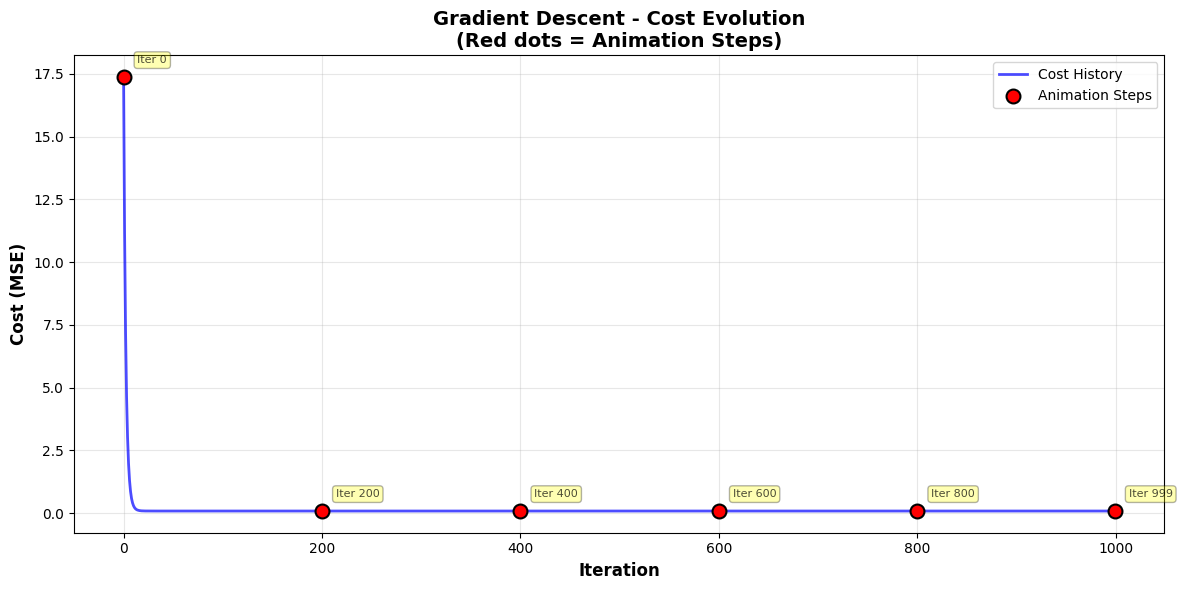

Biểu đồ model iteration 0 đã lưu: mlr_gd_model_iter_0000.png


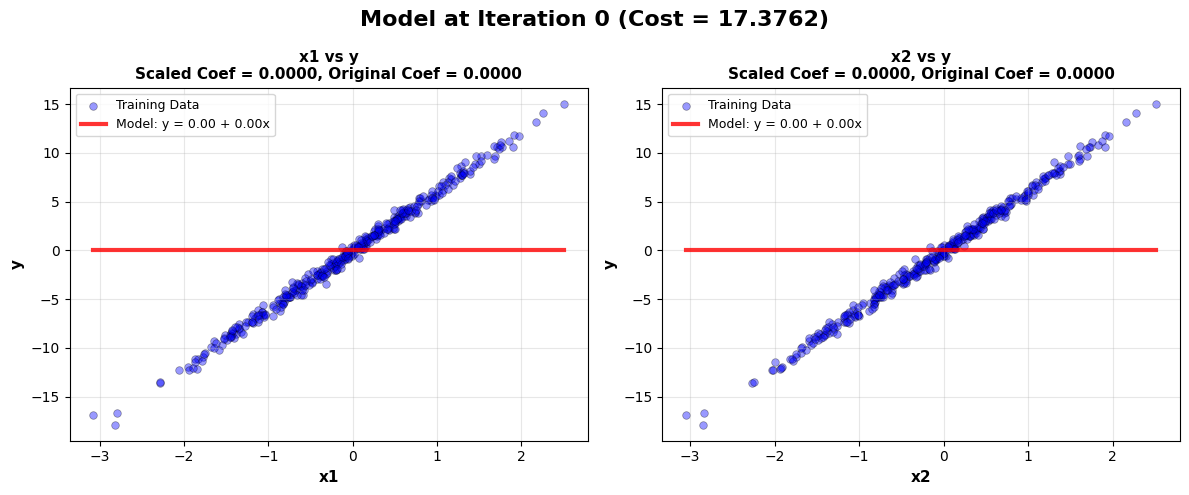

Biểu đồ model iteration 200 đã lưu: mlr_gd_model_iter_0200.png


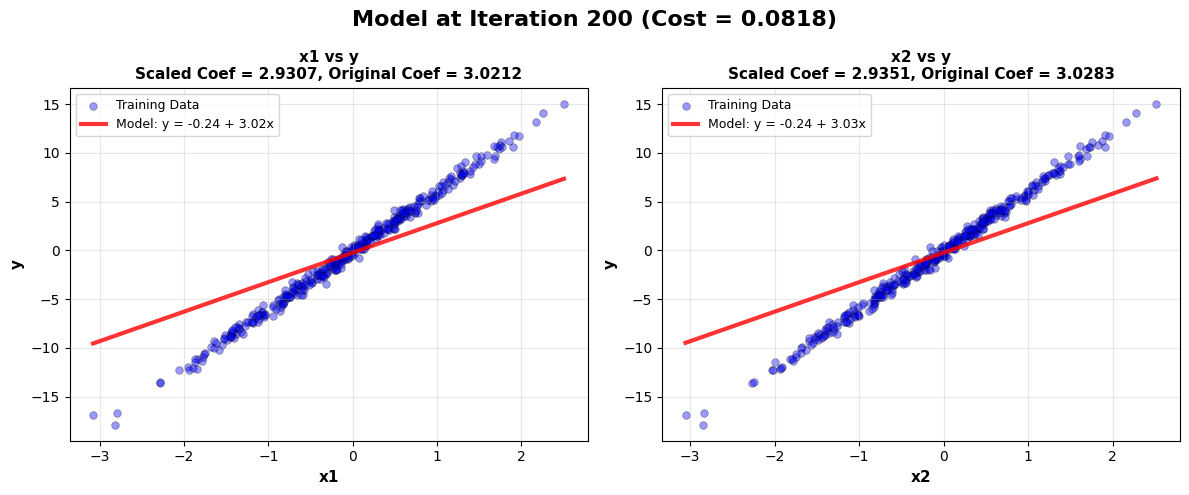

Biểu đồ model iteration 400 đã lưu: mlr_gd_model_iter_0400.png


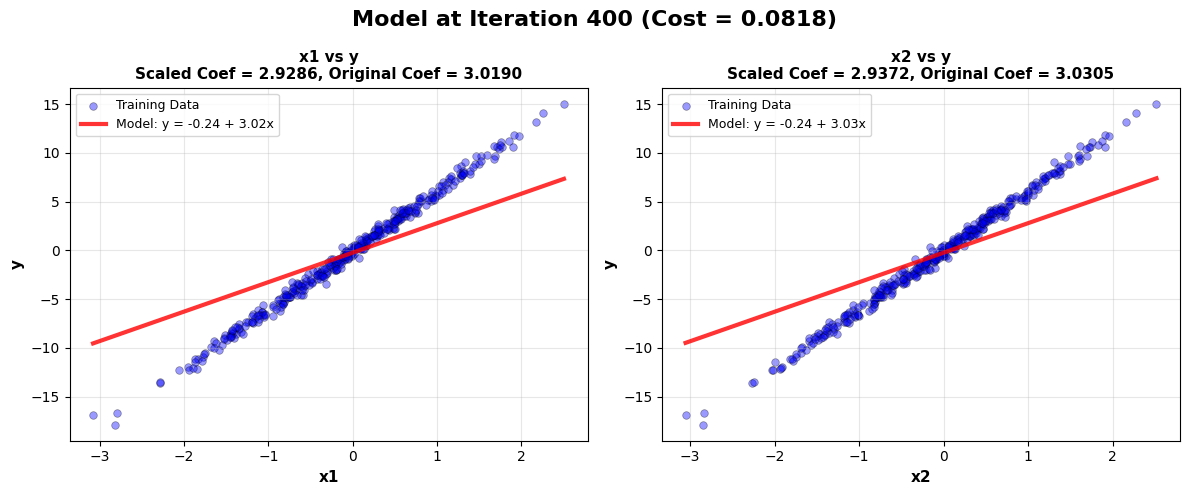

Biểu đồ model iteration 600 đã lưu: mlr_gd_model_iter_0600.png


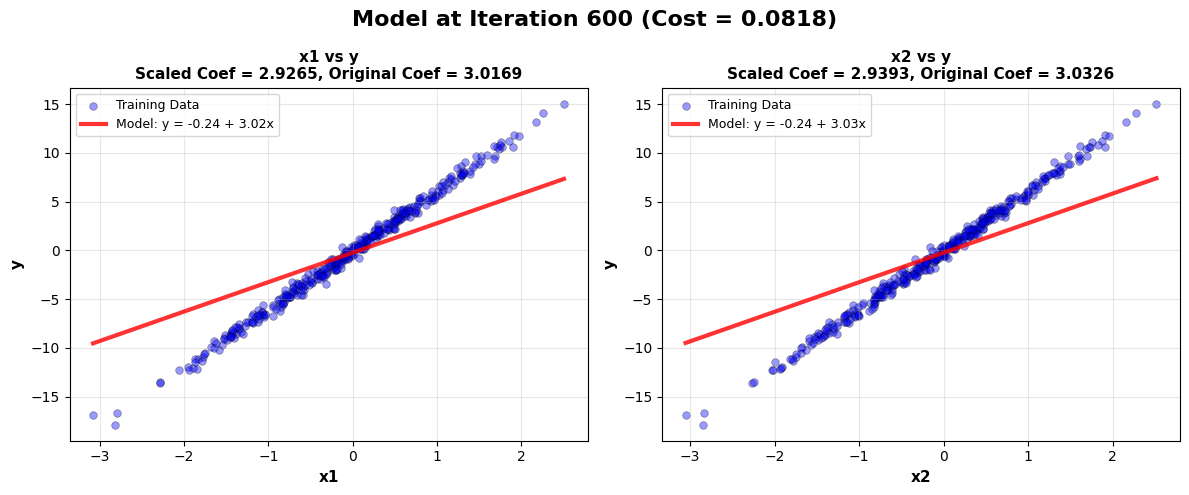

Biểu đồ model iteration 800 đã lưu: mlr_gd_model_iter_0800.png


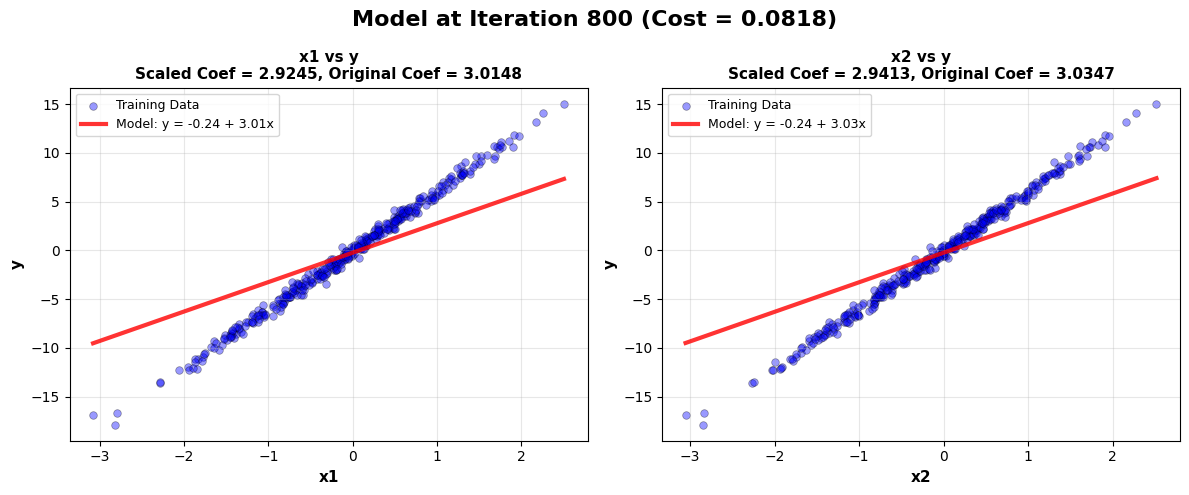

Biểu đồ model iteration 999 đã lưu: mlr_gd_model_iter_0999.png


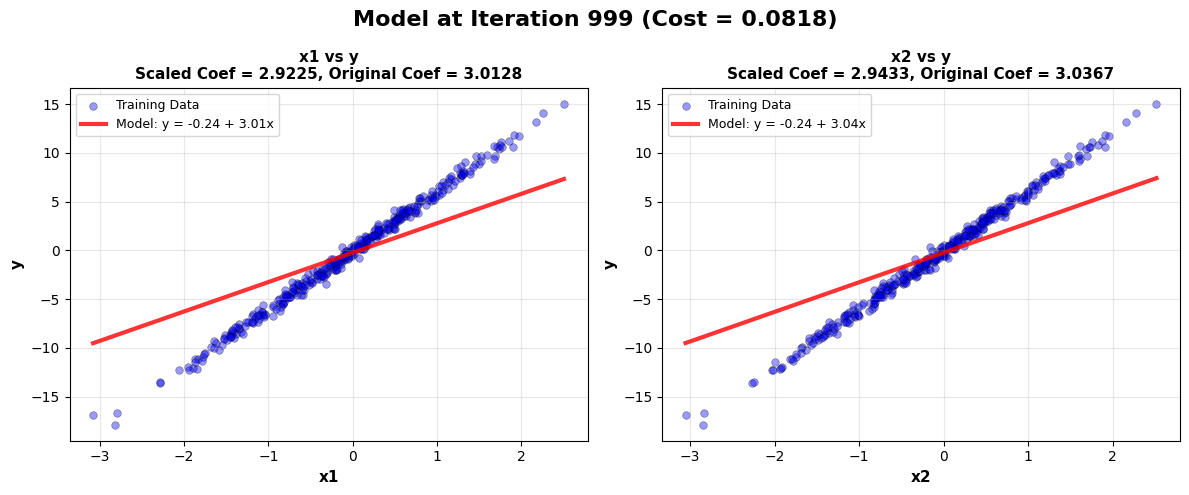


Đã lưu 6 biểu đồ model evolution!
Biểu đồ coefficient trajectories đã lưu: mlr_gd_trajectories.png


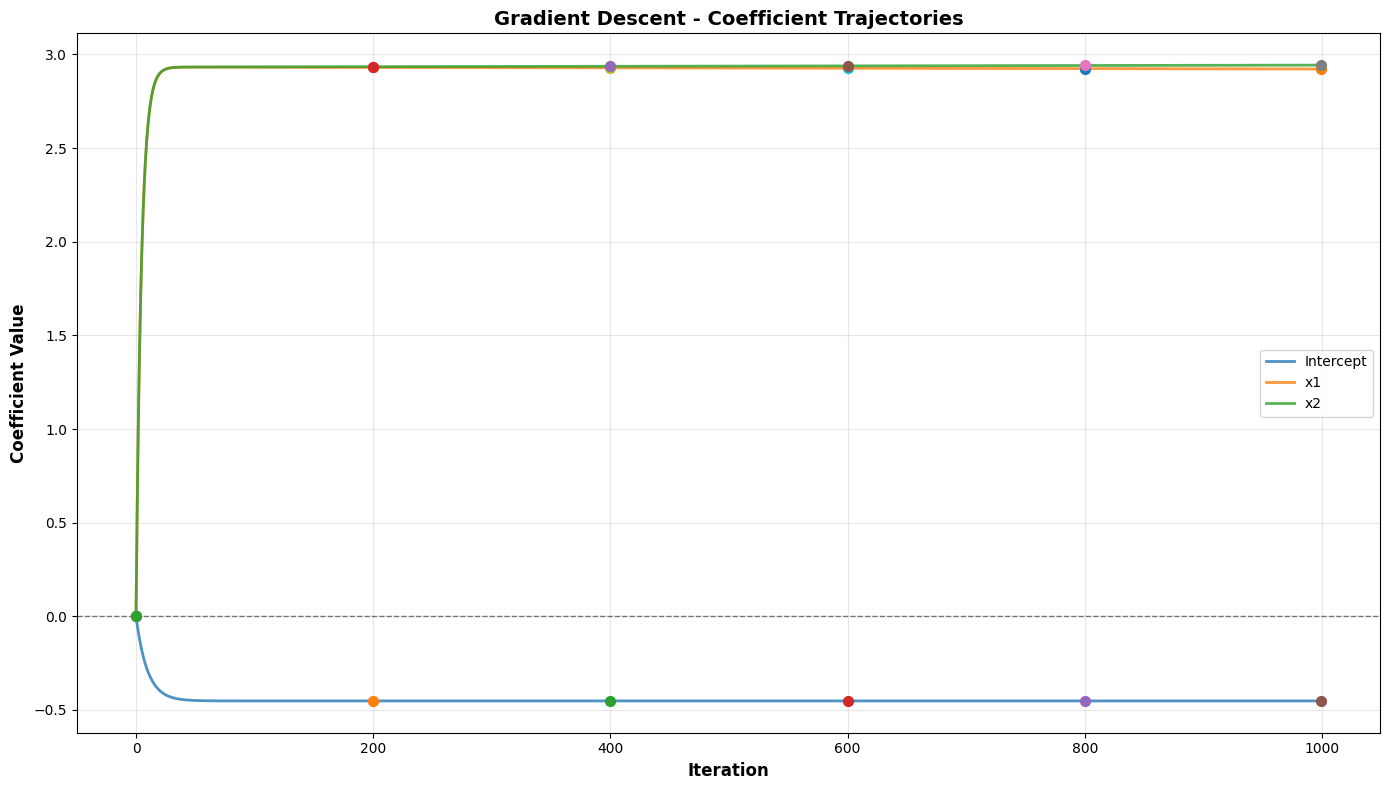


HUẤN LUYỆN MODEL HOÀN TẤT

KẾT QUẢ ĐÁNH GIÁ MODEL

TRAIN SET:
  MSE:  0.1637
  RMSE: 0.4046
  MAE:  0.3146
  R²:   0.9953

VALIDATION SET:
  MSE:  0.1628
  RMSE: 0.4035
  MAE:  0.3210
  R²:   0.9954

TEST SET:
  MSE:  0.1604
  RMSE: 0.4005
  MAE:  0.3254
  R²:   0.9953

HỆ SỐ CỦA MODEL
Intercept (hệ số chặn): -0.4519

Hệ số của các đặc trưng:
  x1                       :     2.9225
  x2                       :     2.9433

Biểu đồ đã được lưu: mlr_results.png


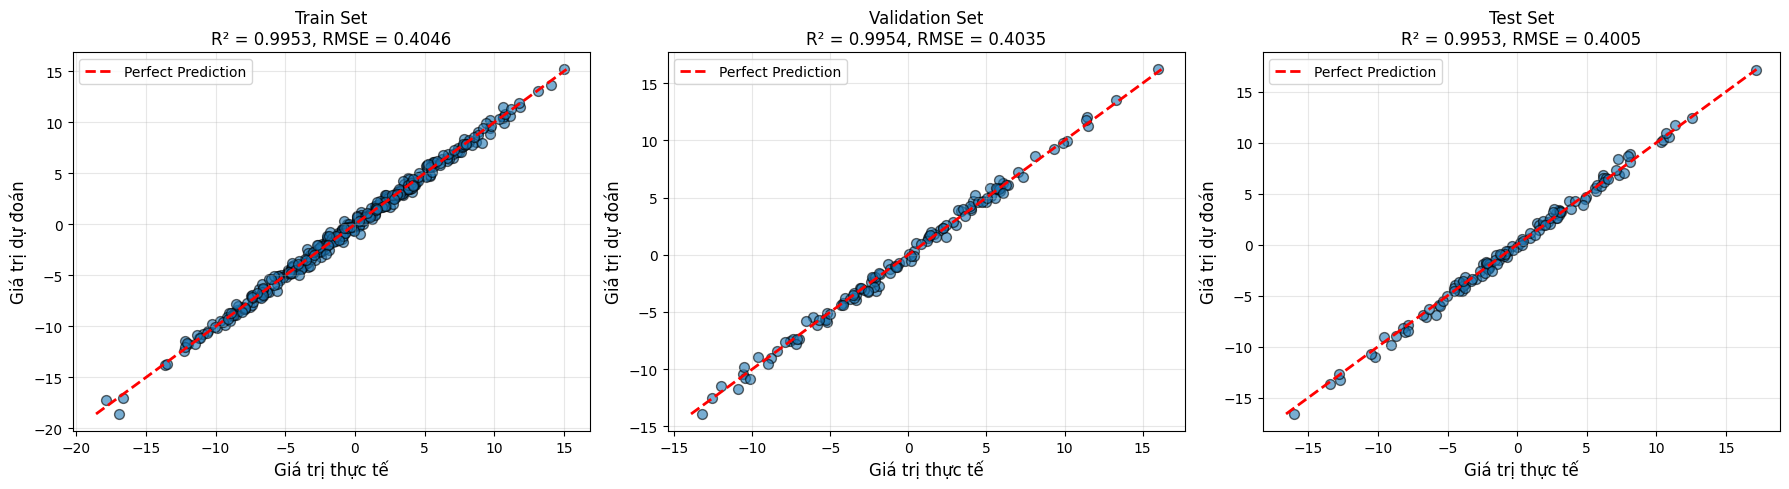

Biểu đồ phần dư đã được lưu: mlr_residuals.png


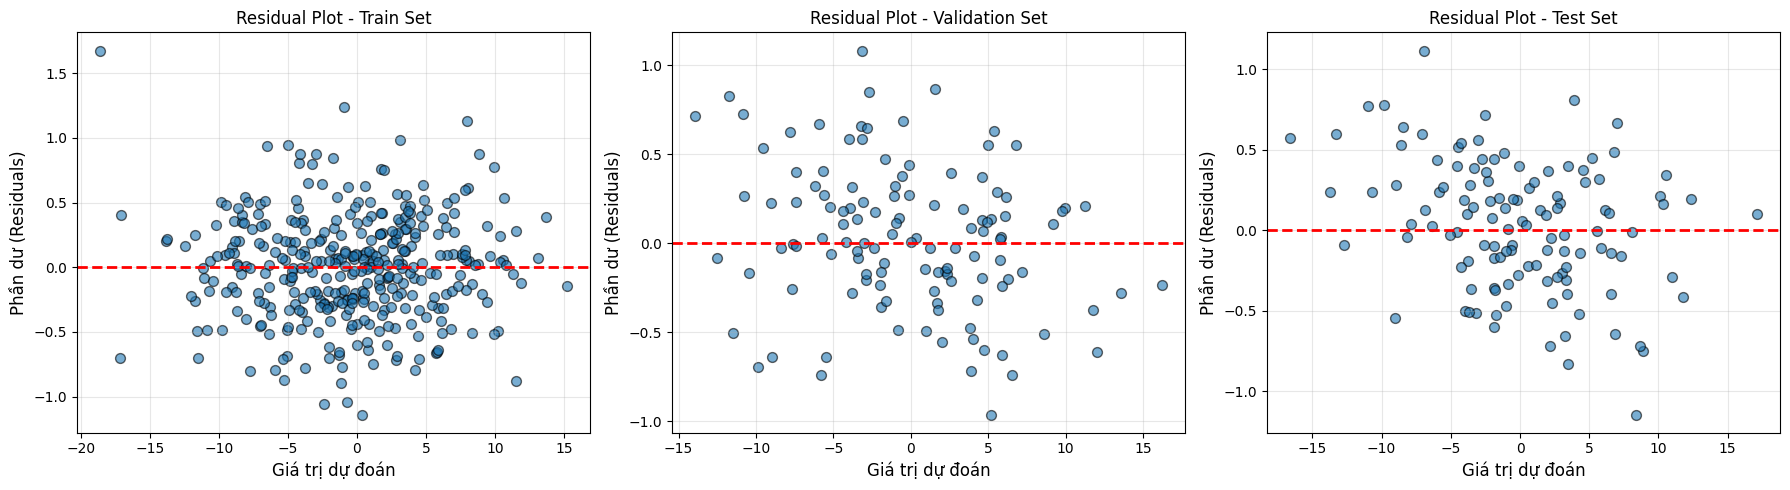


HOÀN TẤT!


In [14]:
results = train_mlr_model_with_animation(
    df, 
    target_col=target_col,
    use_gradient_descent=True,      # Bật Gradient Descent
    learning_rate=0.1,              # Tốc độ học
    n_iterations=1000,               # Số vòng lặp
    animate_steps=True,              # BẬT ANIMATION ⭐
    animation_interval=200           # Hiển thị mỗi 100 iterations
)

In [18]:
check_multicollinearity_vif(df, features=['x1','x2'])


KIỂM TRA ĐA CỘNG TUYẾN (VIF - Variance Inflation Factor)
Số lượng features: 2
Ngưỡng VIF: 10

Hướng dẫn:
  VIF < 5:      Không có vấn đề
  5 <= VIF < 10: Đa cộng tuyến vừa phải
  VIF >= 10:     Đa cộng tuyến nghiêm trọng

KẾT QUẢ VIF
Feature        VIF       Status
     x1 403.921555 Nghiêm trọng
     x2 403.921555 Nghiêm trọng

THỐNG KÊ
VIF cao nhất: 403.92 (x1)
VIF trung bình: 403.92
Số features có VIF >= 10: 2

⚠️  CẢNH BÁO: Phát hiện đa cộng tuyến!
Các features có VIF >= 10:
  - x1: VIF = 403.92
  - x2: VIF = 403.92


{'vif_data':   Feature         VIF        Status
 0      x1  403.921555  Nghiêm trọng
 1      x2  403.921555  Nghiêm trọng,
 'high_vif_features': ['x1', 'x2'],
 'max_vif': 403.9215546166326,
 'mean_vif': np.float64(403.9215546166326),
 'has_multicollinearity': True,
 'threshold': 10,
 'features': ['x1', 'x2']}